# 6.4 — Visualisasi Sirkuit Quantum (matplotlib)

Menggambar **seluruh feature map** dari `model/quantum/estimator.py`
(`circuits.py`, `custom_encode_circuits.py`, `custom_gate_circuits.py`)
menggunakan drawer `mpl` bawaan Qiskit.

Jumlah qubit (`N_QUBITS`) **diambil dari dataset yang telah di-PCA** — yaitu
banyaknya principal component untuk mempertahankan `PCA_THRESH` (95%) variance,
identik dengan konfigurasi di `6.3_compare_all_circuits_pqk.ipynb`.

Gambar tiap sirkuit juga disimpan ke `results/circuits/`.

In [1]:
import sys
import os
from pathlib import Path
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())
project_root = Path(os.environ["PROJECT_ROOT"])
print(f"Project root: {project_root}")
sys.path.append(os.path.abspath(project_root))


Project root: c:\`Bioinformatics\quantum-gesang\codes


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.decomposition import PCA
from qiskit.circuit import ParameterVector
from model.quantum.estimator import QuantumKernelEstimator


In [3]:
feature_cols = [
    "MQ3", "TGS822", "TGS2602", "MQ5", "MQ138", "TGS2620",
    "TGS813", "TGS2600", "TGS2611", "TGS2603", "Humidity", "Celsius",
]
target_cols = "Kategori"

# ── Sirkuit (sinkron dgn circuit_creators di estimator.py) ───────────────────
CIRCUIT_FAMILIES = {
    "Dasar (IQP / Pauli) — circuits.py": [
        "full", "linear", "circular", "pauli_x", "pauli_y", "pauli_z",
    ],
    "Custom encoding — custom_encode_circuits.py": [
        "full_quadratic", "linear_quadratic", "circular_quadratic",
        "full_cosine", "linear_cosine", "circular_cosine",
        "full_selisih", "linear_selisih", "circular_selisih",
    ],
    "Custom gate — custom_gate_circuits.py": [
        "x_full", "x_linear", "x_circular", "y_full", "y_linear", "y_circular",
    ],
    "Custom topology - custom_topology_circuits.py": [
        "star"
    ]
}
ALL_CIRCUITS = [c for cs in CIRCUIT_FAMILIES.values() for c in cs]

LAMBDA_     = 0.3
PCA_THRESH  = 0.95
DATASET_SIZE = 10000     # 500 | 1000 | 5000 | 10000

scalability_datasets = {
    500:   os.path.join(project_root, "dataset", "Dataset_TehHijau500.csv"),
    1000:  os.path.join(project_root, "dataset", "Dataset_TehHijau1k.csv"),
    5000:  os.path.join(project_root, "dataset", "Dataset_TehHijau5k.csv"),
    10000: os.path.join(project_root, "dataset", "Dataset_TehHijau.csv"),
}


## Tentukan `N_QUBITS` dari dataset yang di-PCA

Dataset    : c:\`Bioinformatics\quantum-gesang\codes\dataset\Dataset_TehHijau.csv  (X=(10409, 12))
PCA thresh : 95%  -> N_QUBITS = 4


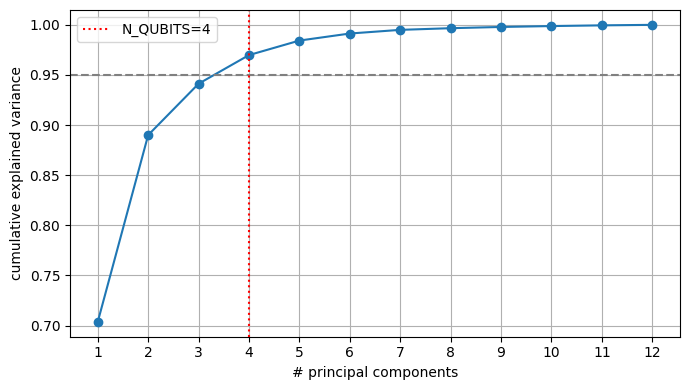

In [4]:
df = pd.read_csv(scalability_datasets[DATASET_SIZE])
X = df[feature_cols].values

pca = PCA(n_components=X.shape[1]).fit(X)
cumvar = np.cumsum(pca.explained_variance_ratio_)
N_QUBITS = int(np.argmax(cumvar >= PCA_THRESH) + 1)

print(f"Dataset    : {scalability_datasets[DATASET_SIZE]}  (X={X.shape})")
print(f"PCA thresh : {PCA_THRESH:.0%}  -> N_QUBITS = {N_QUBITS}")

# plot variance utk konteks
plt.figure(figsize=(7, 4))
plt.plot(range(1, X.shape[1] + 1), cumvar, marker="o")
plt.axhline(PCA_THRESH, color="gray", ls="--")
plt.axvline(N_QUBITS, color="red", ls=":", label=f"N_QUBITS={N_QUBITS}")
plt.xlabel("# principal components"); plt.ylabel("cumulative explained variance")
plt.xticks(range(1, X.shape[1] + 1)); plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()


## Helper — bangun feature map & gambar dengan `mpl`

In [5]:
from IPython.display import display

out_dir = Path("./results/circuits")
out_dir.mkdir(parents=True, exist_ok=True)


def build_feature_map(circuit, n_qubits, lambda_=LAMBDA_):
    """Bangun QuantumCircuit feature map untuk sirkuit bernama `circuit`."""
    est = QuantumKernelEstimator(kernel=circuit, n_qubits=n_qubits, lambda_=lambda_)
    return est._build_feature_map(n_qubits)


def draw_circuit(circuit, n_qubits=N_QUBITS, save=True):
    qc = build_feature_map(circuit, n_qubits)
    fig = qc.draw("mpl", fold=-1, style={"name": "iqp"})
    fig.suptitle(f"{circuit}  (n_qubits={n_qubits}, lambda={LAMBDA_})",
                 fontsize=12, fontweight="bold")
    if save:
        fig.savefig(out_dir / f"{circuit}_q{n_qubits}.png", dpi=150, bbox_inches="tight")
    display(fig)        # tampilkan inline di cell
    plt.close(fig)      # cegah figure dobel ter-render
    return qc


## Gambar semua sirkuit (dikelompokkan per keluarga)

### Dasar (IQP / Pauli) — circuits.py

**`full`**

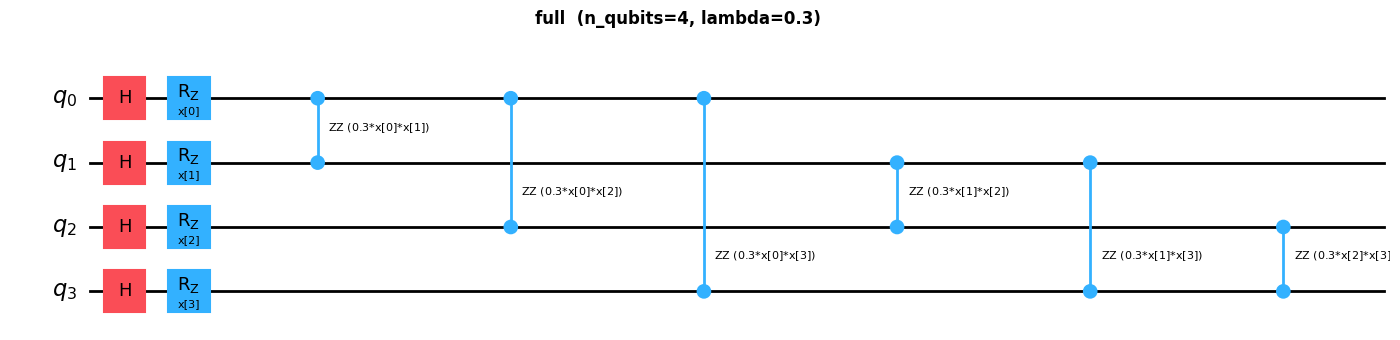

**`linear`**

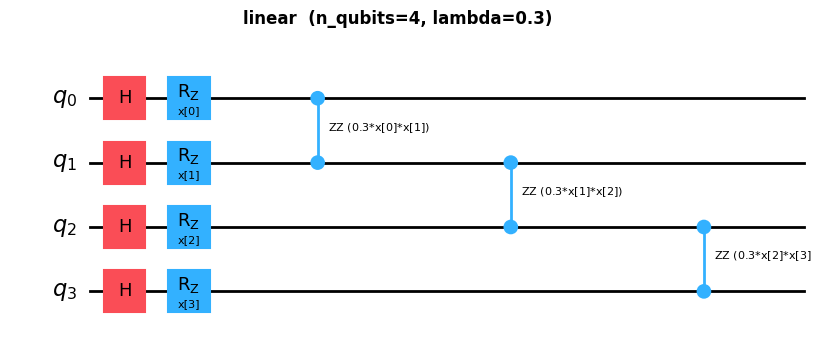

**`circular`**

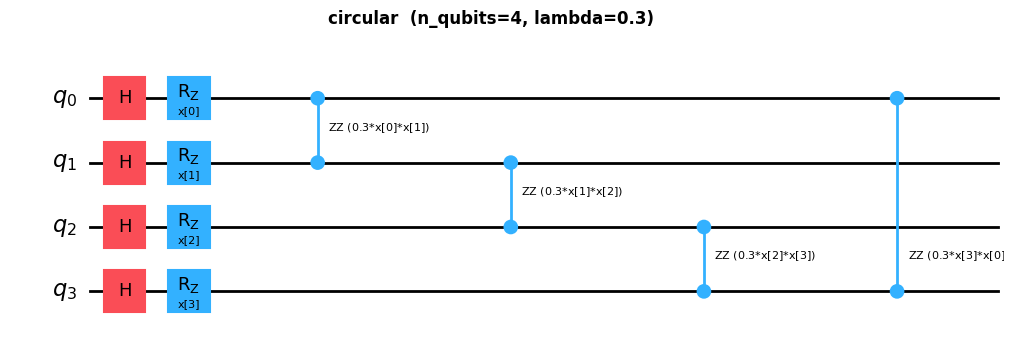

**`pauli_x`**

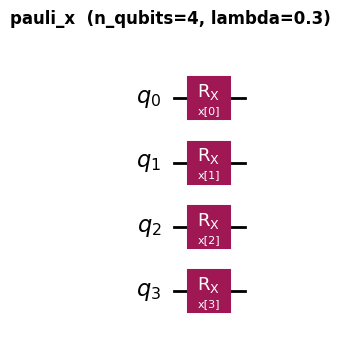

**`pauli_y`**

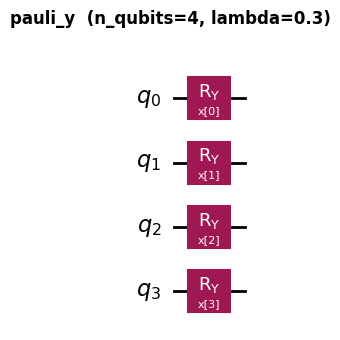

**`pauli_z`**

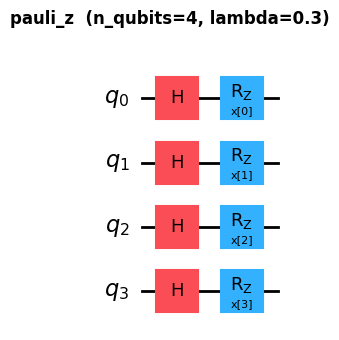

### Custom encoding — custom_encode_circuits.py

**`full_quadratic`**

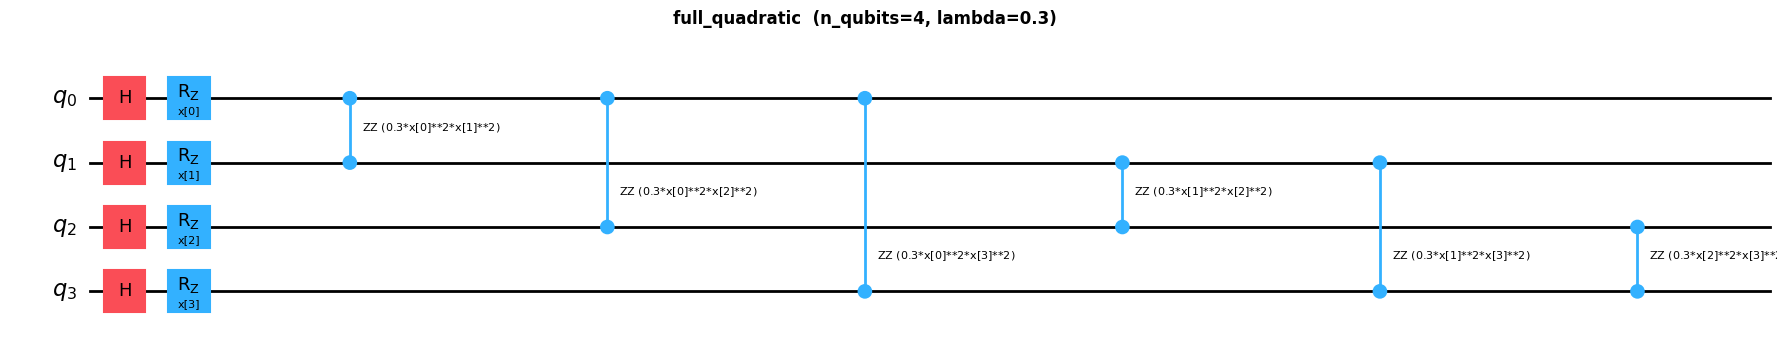

**`linear_quadratic`**

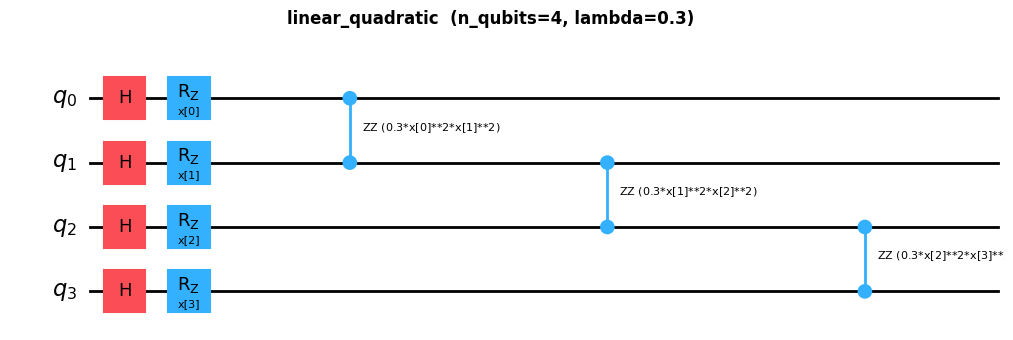

**`circular_quadratic`**

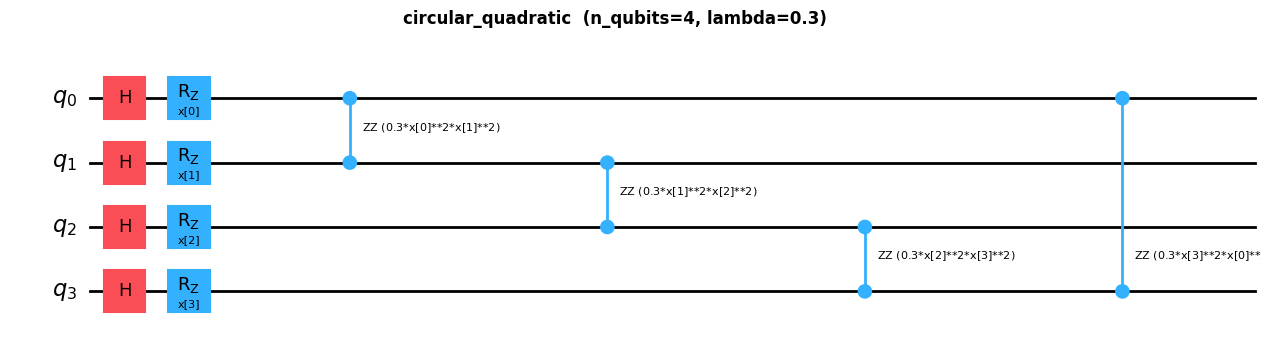

**`full_cosine`**

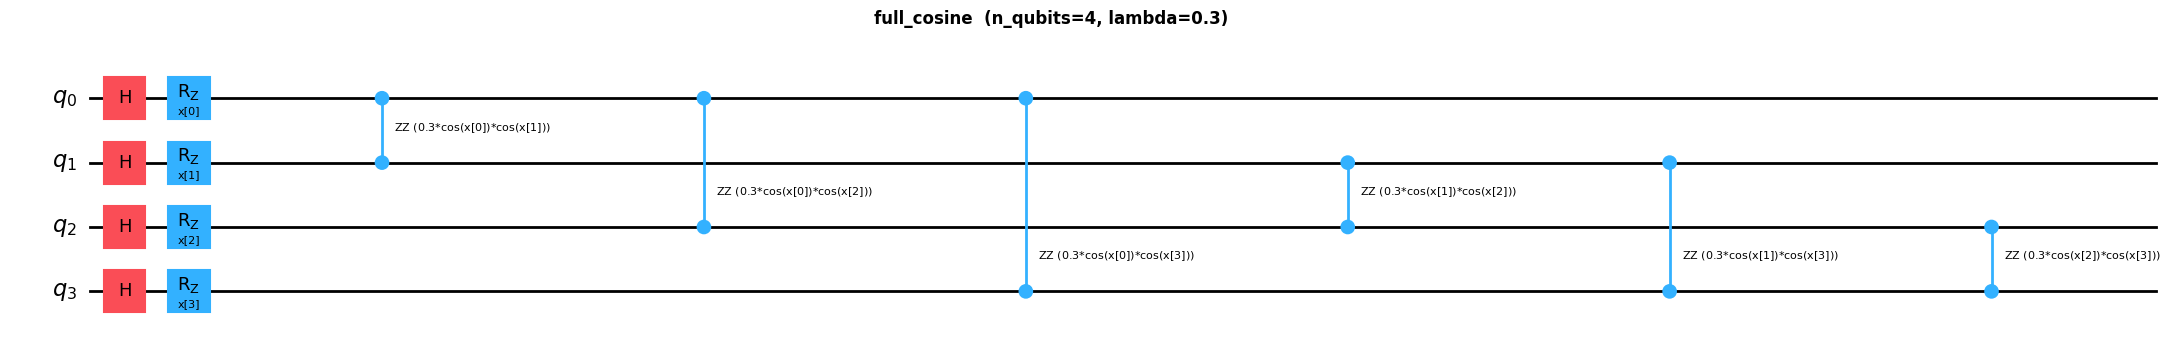

**`linear_cosine`**

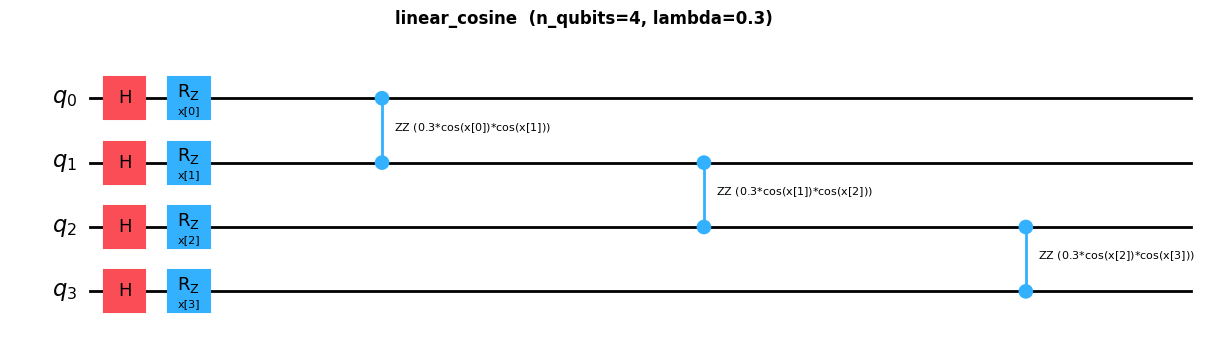

**`circular_cosine`**

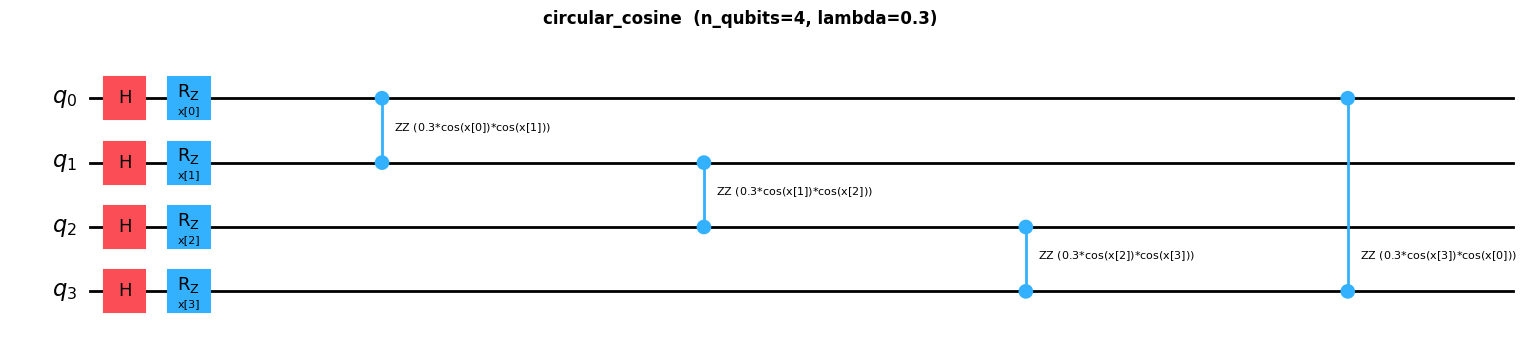

**`full_selisih`**

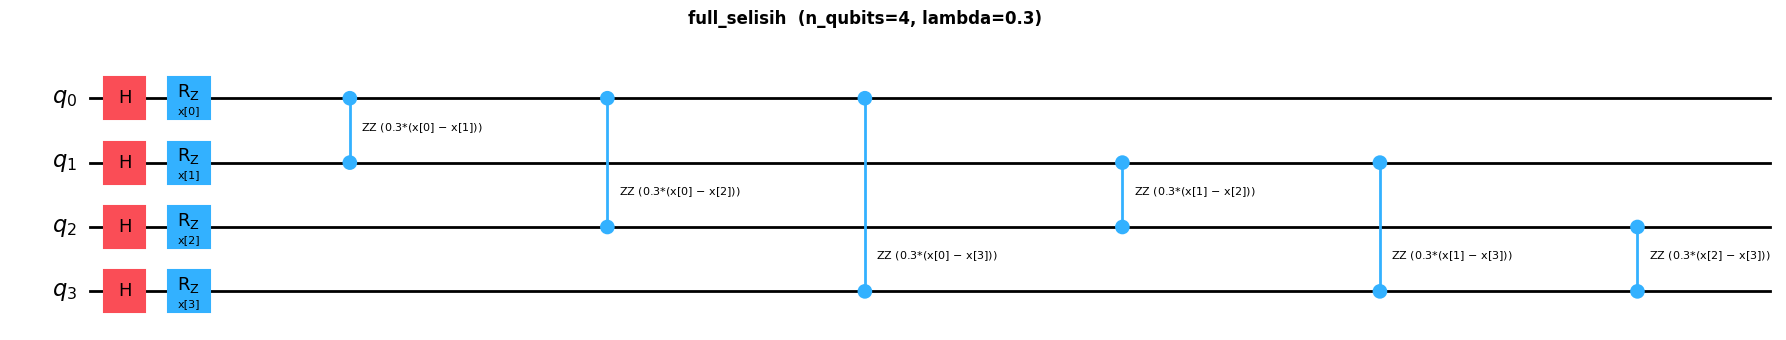

**`linear_selisih`**

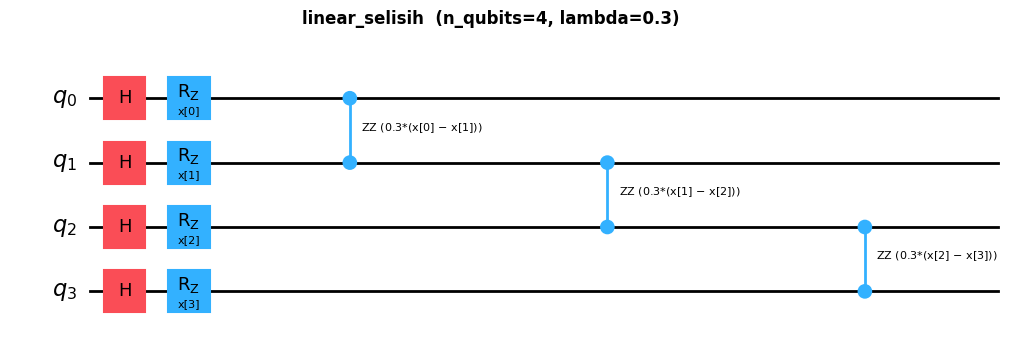

**`circular_selisih`**

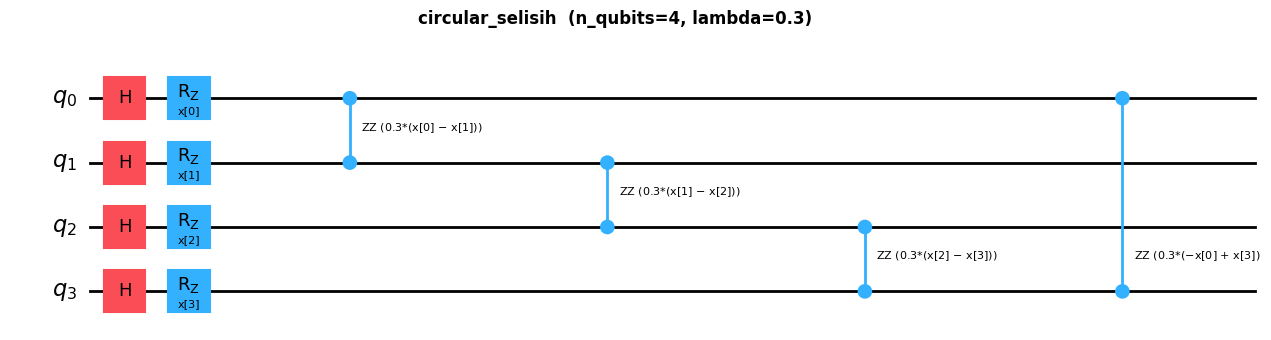

### Custom gate — custom_gate_circuits.py

**`x_full`**

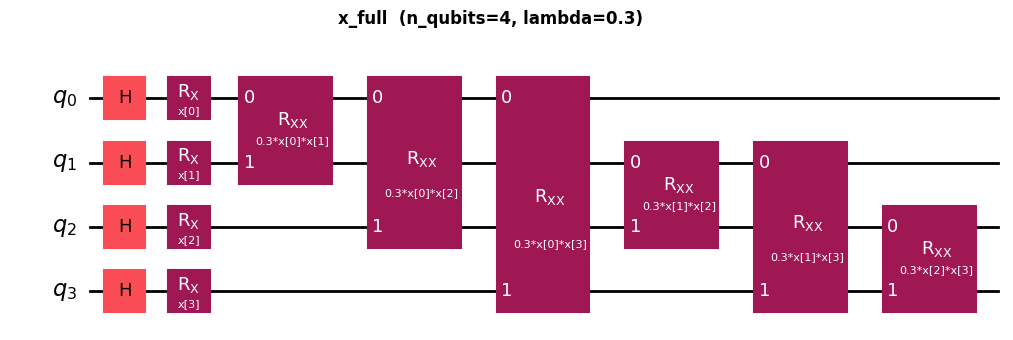

**`x_linear`**

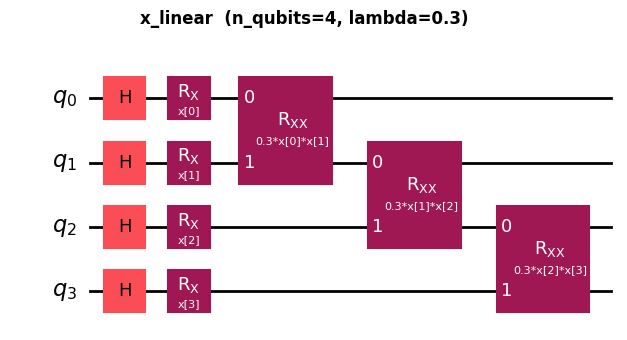

**`x_circular`**

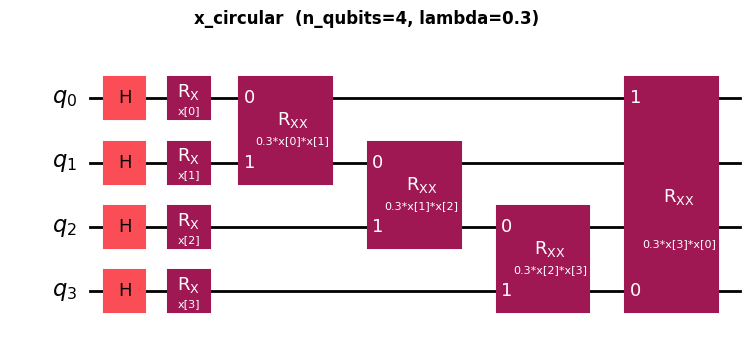

**`y_full`**

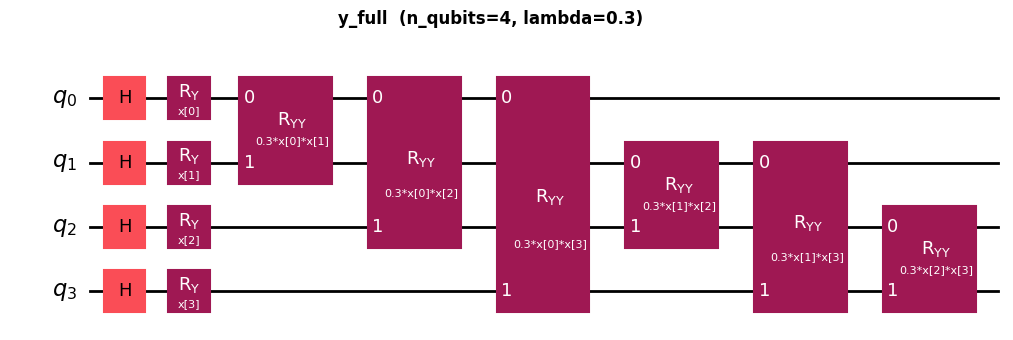

**`y_linear`**

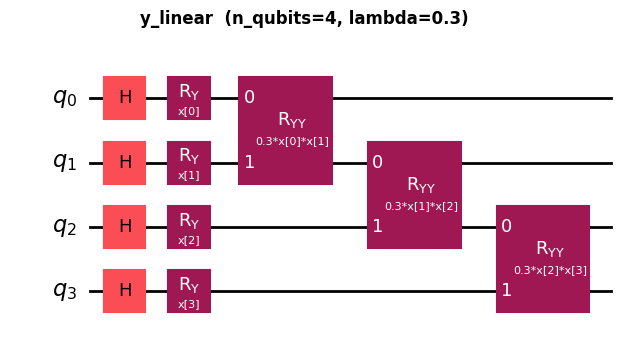

**`y_circular`**

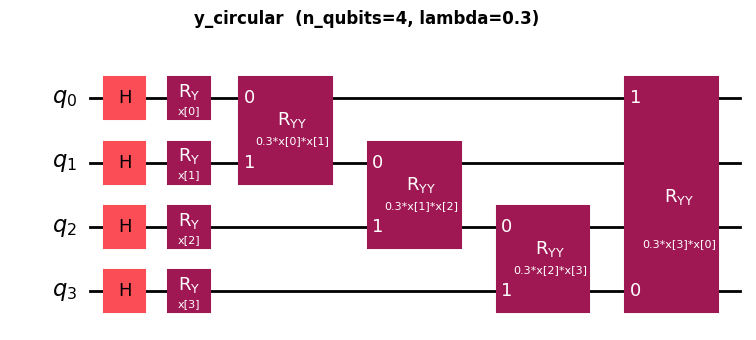

### Custom topology - custom_topology_circuits.py

**`star`**

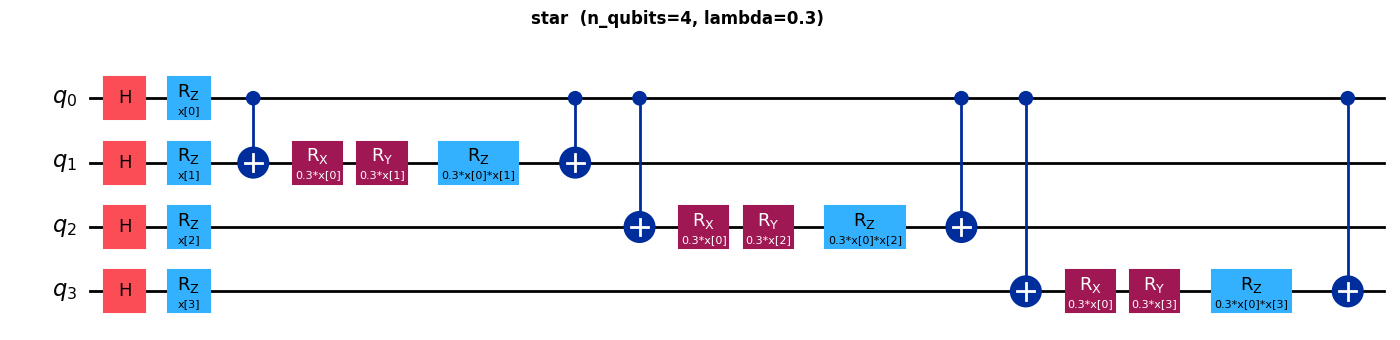

Semua gambar disimpan di: C:\`Bioinformatics\quantum-gesang\codes\notebooks\results\circuits


In [6]:
from IPython.display import display, Markdown

for family, circuits in CIRCUIT_FAMILIES.items():
    display(Markdown(f"### {family}"))
    for c in circuits:
        display(Markdown(f"**`{c}`**"))
        draw_circuit(c, N_QUBITS)

print(f"Semua gambar disimpan di: {out_dir.resolve()}")


## ZZFeatureMap (bawaan Qiskit)

Sebagai pembanding, di bawah ini `ZZFeatureMap` bawaan Qiskit
(`qiskit.circuit.library.zz_feature_map`) — entanglement penuh, `reps=2`.
Gate dasarnya (`h`, `p`, `cx`) sudah langsung terlihat, lalu digambar
dengan drawer `mpl` dan disimpan ke `results/circuits/`.

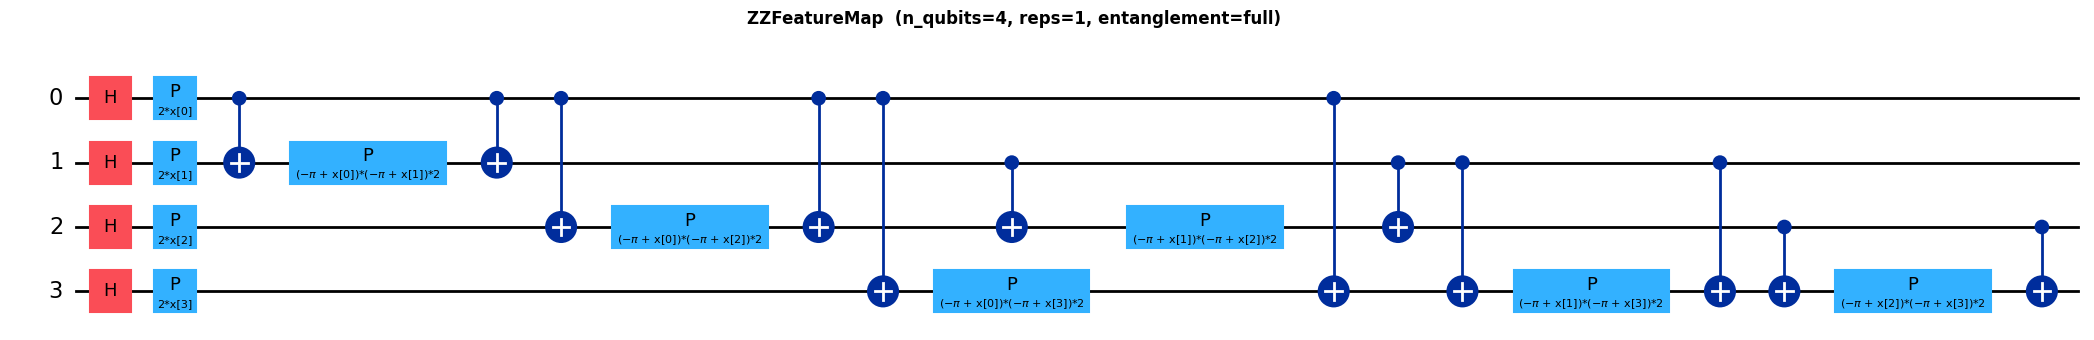

ZZFeatureMap: num_qubits=4, depth=17, size=26, ops={'cx': 12, 'p': 10, 'h': 4}


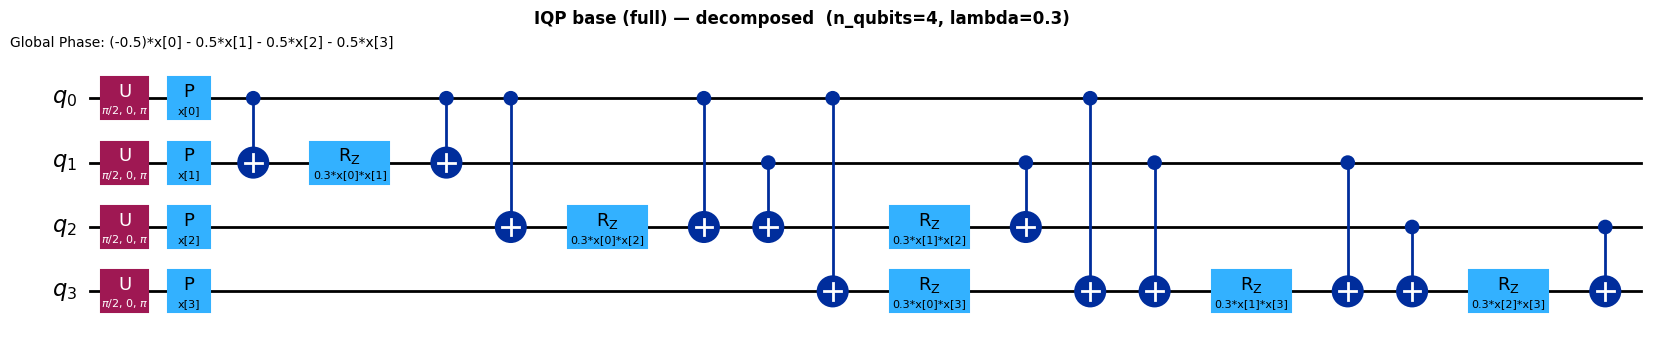

IQP base (decomposed): num_qubits=4, depth=17, size=26, ops={'cx': 12, 'rz': 6, 'u': 4, 'p': 4}


In [17]:
from qiskit.circuit.library import zz_feature_map

# ZZFeatureMap bawaan Qiskit (entanglement penuh, reps=2)
# Sirkuit sudah dalam gate dasar (h / p / cx) sehingga langsung bisa digambar.
zz = zz_feature_map(feature_dimension=N_QUBITS, reps=1, entanglement="full")

fig = zz.draw("mpl", fold=-1, style={"name": "iqp"})
fig.suptitle(f"ZZFeatureMap  (n_qubits={N_QUBITS}, reps=1, entanglement=full)",
             fontsize=12, fontweight="bold")
fig.savefig(out_dir / f"zzfeaturemap_q{N_QUBITS}.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)

print("ZZFeatureMap:",
      f"num_qubits={zz.num_qubits}, depth={zz.depth()}, size={zz.size()},",
      f"ops={dict(zz.count_ops())}")

# ── IQP base (sirkuit "full") di-decompose ke gate dasar ─────────────────────
# .decompose() menjabarkan rzz menjadi gate dasar (cx, rz, dst.)
iqp_base = build_feature_map("full", N_QUBITS)
iqp_decomposed = iqp_base.decompose()

fig = iqp_decomposed.draw("mpl", fold=-1, style={"name": "iqp"})
fig.suptitle(f"IQP base (full) — decomposed  (n_qubits={N_QUBITS}, lambda={LAMBDA_})",
             fontsize=12, fontweight="bold")
fig.savefig(out_dir / f"iqp_full_decomposed_q{N_QUBITS}.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)

print("IQP base (decomposed):",
      f"num_qubits={iqp_decomposed.num_qubits}, depth={iqp_decomposed.depth()},",
      f"size={iqp_decomposed.size()}, ops={dict(iqp_decomposed.count_ops())}")


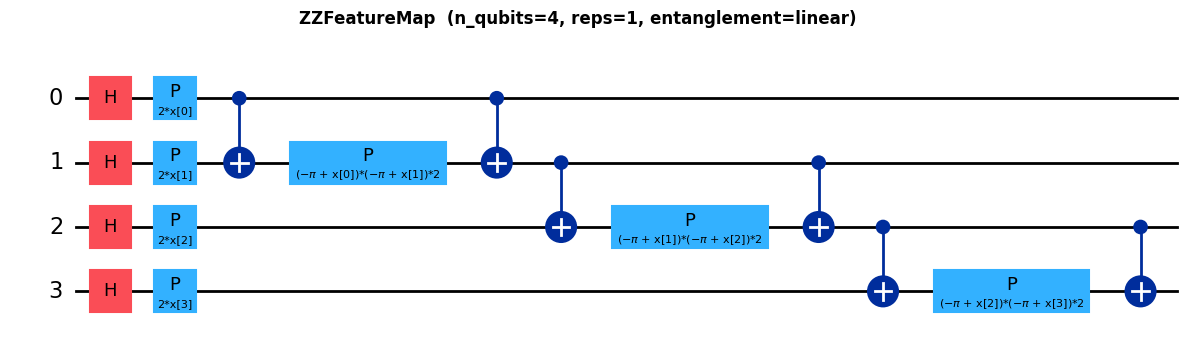

ZZFeatureMap: num_qubits=4, depth=11, size=17, ops={'p': 7, 'cx': 6, 'h': 4}


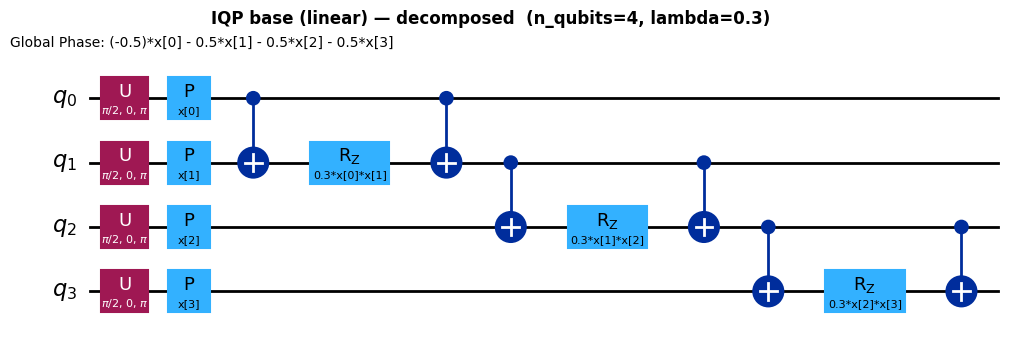

IQP base (decomposed): num_qubits=4, depth=11, size=17, ops={'cx': 6, 'u': 4, 'p': 4, 'rz': 3}


In [19]:
from qiskit.circuit.library import zz_feature_map

# ZZFeatureMap bawaan Qiskit (entanglement penuh, reps=2)
# Sirkuit sudah dalam gate dasar (h / p / cx) sehingga langsung bisa digambar.
zz = zz_feature_map(feature_dimension=N_QUBITS, reps=1, entanglement="linear")

fig = zz.draw("mpl", fold=-1, style={"name": "iqp"})
fig.suptitle(f"ZZFeatureMap  (n_qubits={N_QUBITS}, reps=1, entanglement=linear)",
             fontsize=12, fontweight="bold")
fig.savefig(out_dir / f"zzfeaturemap_q{N_QUBITS}.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)

print("ZZFeatureMap:",
      f"num_qubits={zz.num_qubits}, depth={zz.depth()}, size={zz.size()},",
      f"ops={dict(zz.count_ops())}")

# ── IQP base (sirkuit "linear") di-decompose ke gate dasar ─────────────────────
# .decompose() menjabarkan rzz menjadi gate dasar (cx, rz, dst.)
iqp_base = build_feature_map("linear", N_QUBITS)
iqp_decomposed = iqp_base.decompose()

fig = iqp_decomposed.draw("mpl", fold=-1, style={"name": "iqp"})
fig.suptitle(f"IQP base (linear) — decomposed  (n_qubits={N_QUBITS}, lambda={LAMBDA_})",
             fontsize=12, fontweight="bold")
fig.savefig(out_dir / f"iqp_linear_decomposed_q{N_QUBITS}.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)

print("IQP base (decomposed):",
      f"num_qubits={iqp_decomposed.num_qubits}, depth={iqp_decomposed.depth()},",
      f"size={iqp_decomposed.size()}, ops={dict(iqp_decomposed.count_ops())}")


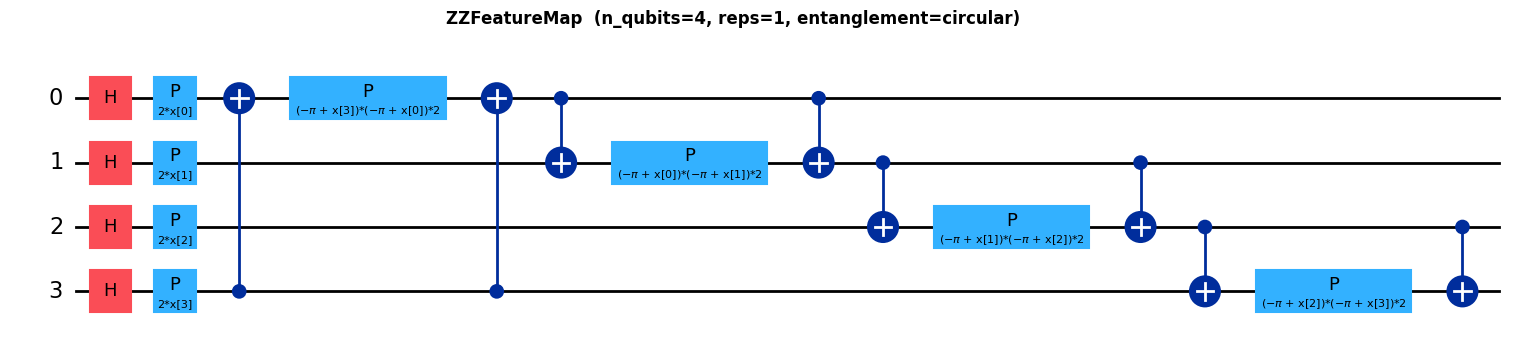

ZZFeatureMap: num_qubits=4, depth=14, size=20, ops={'p': 8, 'cx': 8, 'h': 4}


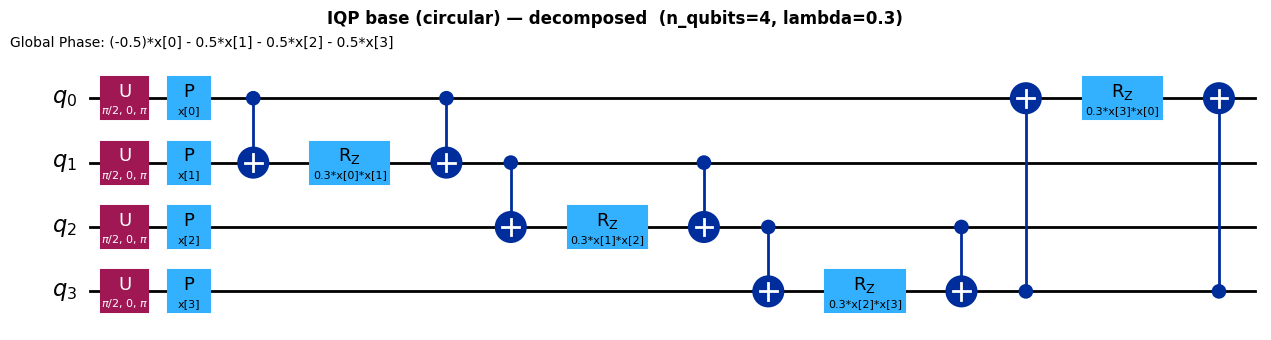

IQP base (decomposed): num_qubits=4, depth=14, size=20, ops={'cx': 8, 'u': 4, 'p': 4, 'rz': 4}


In [22]:
from qiskit.circuit.library import zz_feature_map

# ZZFeatureMap bawaan Qiskit (entanglement penuh, reps=2)
# Sirkuit sudah dalam gate dasar (h / p / cx) sehingga langsung bisa digambar.
zz = zz_feature_map(feature_dimension=N_QUBITS, reps=1, entanglement="circular")

fig = zz.draw("mpl", fold=-1, style={"name": "iqp"})
fig.suptitle(f"ZZFeatureMap  (n_qubits={N_QUBITS}, reps=1, entanglement=circular)",
             fontsize=12, fontweight="bold")
fig.savefig(out_dir / f"zzfeaturemap_q{N_QUBITS}.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)

print("ZZFeatureMap:",
      f"num_qubits={zz.num_qubits}, depth={zz.depth()}, size={zz.size()},",
      f"ops={dict(zz.count_ops())}")

# ── IQP base (sirkuit "circular") di-decompose ke gate dasar ─────────────────────
# .decompose() menjabarkan rzz menjadi gate dasar (cx, rz, dst.)
iqp_base = build_feature_map("circular", N_QUBITS)
iqp_decomposed = iqp_base.decompose()

fig = iqp_decomposed.draw("mpl", fold=-1, style={"name": "iqp"})
fig.suptitle(f"IQP base (circular) — decomposed  (n_qubits={N_QUBITS}, lambda={LAMBDA_})",
             fontsize=12, fontweight="bold")
fig.savefig(out_dir / f"iqp_circular_decomposed_q{N_QUBITS}.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)

print("IQP base (decomposed):",
      f"num_qubits={iqp_decomposed.num_qubits}, depth={iqp_decomposed.depth()},",
      f"size={iqp_decomposed.size()}, ops={dict(iqp_decomposed.count_ops())}")


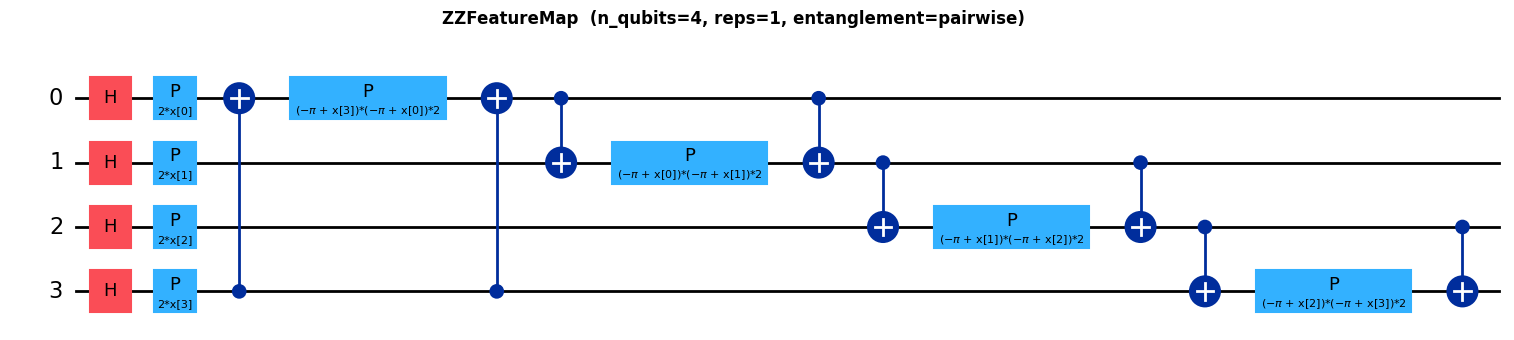

ZZFeatureMap: num_qubits=4, depth=14, size=20, ops={'p': 8, 'cx': 8, 'h': 4}


In [ ]:
from qiskit.circuit.library import zz_feature_map

# ZZFeatureMap bawaan Qiskit (entanglement penuh, reps=2)
# Sirkuit sudah dalam gate dasar (h / p / cx) sehingga langsung bisa digambar.
zz = zz_feature_map(feature_dimension=N_QUBITS, reps=1, entanglement="pairwise")

fig = zz.draw("mpl", fold=-1, style={"name": "iqp"})
fig.suptitle(f"ZZFeatureMap  (n_qubits={N_QUBITS}, reps=1, entanglement=pairwise)",
             fontsize=12, fontweight="bold")
fig.savefig(out_dir / f"zzfeaturemap_q{N_QUBITS}.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)

print("ZZFeatureMap:",
      f"num_qubits={zz.num_qubits}, depth={zz.depth()}, size={zz.size()},",
      f"ops={dict(zz.count_ops())}")

## PauliFeatureMap (bawaan Qiskit)

`PauliFeatureMap` (`qiskit.circuit.library.pauli_feature_map`) adalah generalisasi
dari `ZZFeatureMap`: jenis interaksi diatur lewat argumen `paulis`. Di bawah ini
dua varian sebagai pembanding:

- **`paulis=['Z', 'ZZ']`** — identik dengan `ZZFeatureMap` (rotasi `Z` orde-1 + interaksi `ZZ`).
- **`paulis=['X', 'Y', 'ZZ']`** — rotasi `X` & `Y` orde-1 + interaksi `ZZ`.

Sirkuit di-decompose ke gate dasar lalu disimpan ke `results/circuits/`.

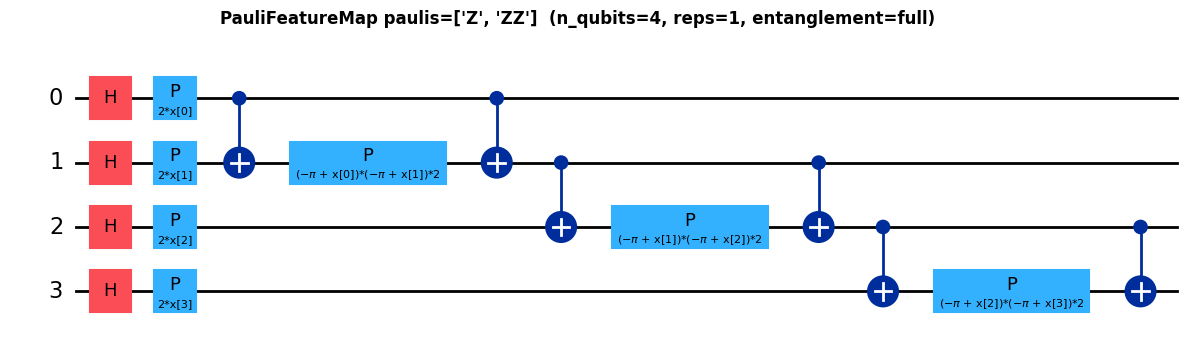

PauliFeatureMap paulis=['Z', 'ZZ']: num_qubits=4, depth=11, size=17, ops={'p': 7, 'cx': 6, 'h': 4}


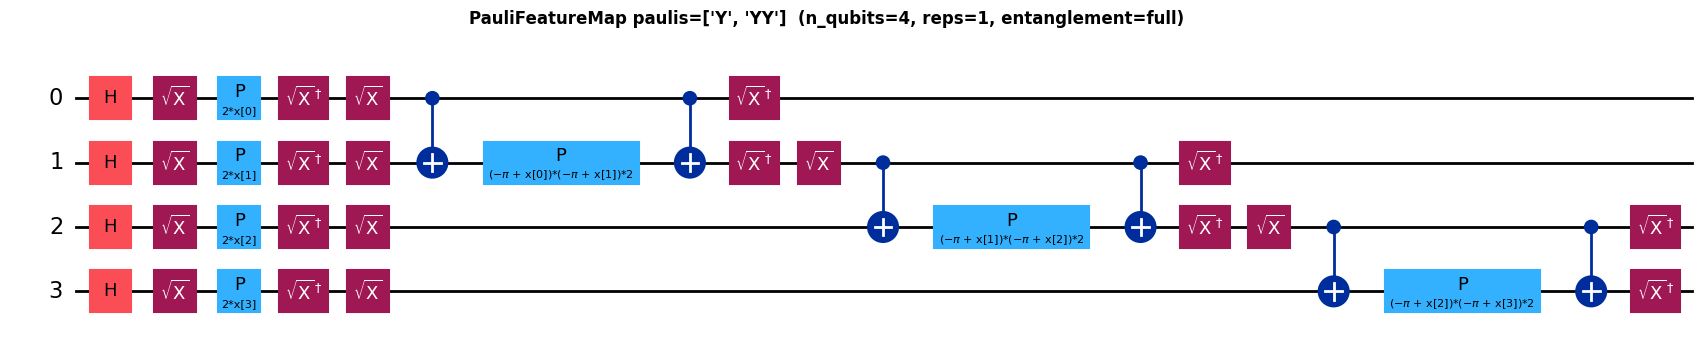

PauliFeatureMap paulis=['Y', 'YY']: num_qubits=4, depth=19, size=37, ops={'sx': 10, 'sxdg': 10, 'p': 7, 'cx': 6, 'h': 4}


In [27]:
from qiskit.circuit.library import pauli_feature_map

# Varian PauliFeatureMap yang digambar: (label, daftar paulis)
pauli_variants = [
    ("Z_ZZ",  ["Z", "ZZ"]),       # setara ZZFeatureMap
    ("X_Y_ZZ", ["Y", "YY"]),
]

for label, paulis in pauli_variants:
    pfm = pauli_feature_map(
        feature_dimension=N_QUBITS, reps=1, entanglement="linear", paulis=paulis,
    )
    pfm_decomposed = pfm

    fig = pfm_decomposed.draw("mpl", fold=-1, style={"name": "iqp"})
    fig.suptitle(f"PauliFeatureMap paulis={paulis}  (n_qubits={N_QUBITS}, reps=1, entanglement=full)",
                 fontsize=12, fontweight="bold")
    fig.savefig(out_dir / f"paulifeaturemap_{label}_q{N_QUBITS}.png", dpi=150, bbox_inches="tight")
    display(fig)
    plt.close(fig)

    print(f"PauliFeatureMap paulis={paulis}:",
          f"num_qubits={pfm.num_qubits}, depth={pfm_decomposed.depth()},",
          f"size={pfm_decomposed.size()}, ops={dict(pfm_decomposed.count_ops())}")


## (Opsional) Ringkasan teks tiap sirkuit

Berguna untuk cek cepat depth / jumlah gate tanpa render mpl.

In [11]:
rows = []
for c in ALL_CIRCUITS:
    qc = build_feature_map(c, N_QUBITS)
    ops = dict(qc.count_ops())
    rows.append({
        "circuit": c,
        "num_qubits": qc.num_qubits,
        "depth": qc.depth(),
        "size": qc.size(),
        "ops": ", ".join(f"{k}:{v}" for k, v in sorted(ops.items())),
    })
pd.DataFrame(rows)


,circuit,num_qubits,depth,size,ops
0,full,4,7,14,"h:4, rz:4, rzz:6"
1,linear,4,5,11,"h:4, rz:4, rzz:3"
2,circular,4,6,12,"h:4, rz:4, rzz:4"
3,pauli_x,4,1,4,rx:4
4,pauli_y,4,1,4,ry:4
5,pauli_z,4,2,8,"h:4, rz:4"
6,full_quadratic,4,7,14,"h:4, rz:4, rzz:6"
7,linear_quadratic,4,5,11,"h:4, rz:4, rzz:3"
8,circular_quadratic,4,6,12,"h:4, rz:4, rzz:4"
9,full_cosine,4,7,14,"h:4, rz:4, rzz:6"
